In [1]:
# Import required libraries 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
# statsmodels is the standard library for detailed regression analysis in Python
import statsmodels.api as sm

%matplotlib inline

In [2]:
# Now we are going to load the auto mpg dataset
df = pd.read_csv('./data/auto-mpg.csv')
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [3]:
# View summary of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


After view the summary as you can see there are 7 Numerical variables and 2 categoricla variables (Horsepower and Car name).

In [4]:
# Checking any missing values
df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64

So right now as you can see there is no missing values in Auto_MPG Dataset.Now we are going to further check if there is value stored as '?' or not.

In [5]:
df['horsepower'].unique()

array(['130', '165', '150', '140', '198', '220', '215', '225', '190',
       '170', '160', '95', '97', '85', '88', '46', '87', '90', '113',
       '200', '210', '193', '?', '100', '105', '175', '153', '180', '110',
       '72', '86', '70', '76', '65', '69', '60', '80', '54', '208', '155',
       '112', '92', '145', '137', '158', '167', '94', '107', '230', '49',
       '75', '91', '122', '67', '83', '78', '52', '61', '93', '148',
       '129', '96', '71', '98', '115', '53', '81', '79', '120', '152',
       '102', '108', '68', '58', '149', '89', '63', '48', '66', '139',
       '103', '125', '133', '138', '135', '142', '77', '62', '132', '84',
       '64', '74', '116', '82'], dtype=object)

After checking the unique values, we found that there is one unique value ('?') which was hidden when I checked the missing value, so now i am going to handle it.

In [6]:
# Replace ? with NaN 
df['horsepower'] = df['horsepower'].replace('?',np.nan)

In [7]:
df['horsepower'] = pd.to_numeric(df['horsepower'],errors="coerce")

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(4), int64(4), object(1)
memory usage: 28.1+ KB


In [9]:
# drop rows any missing value in any columns
df.dropna(inplace=True)

In [10]:
df.shape

(392, 9)

## Visualization

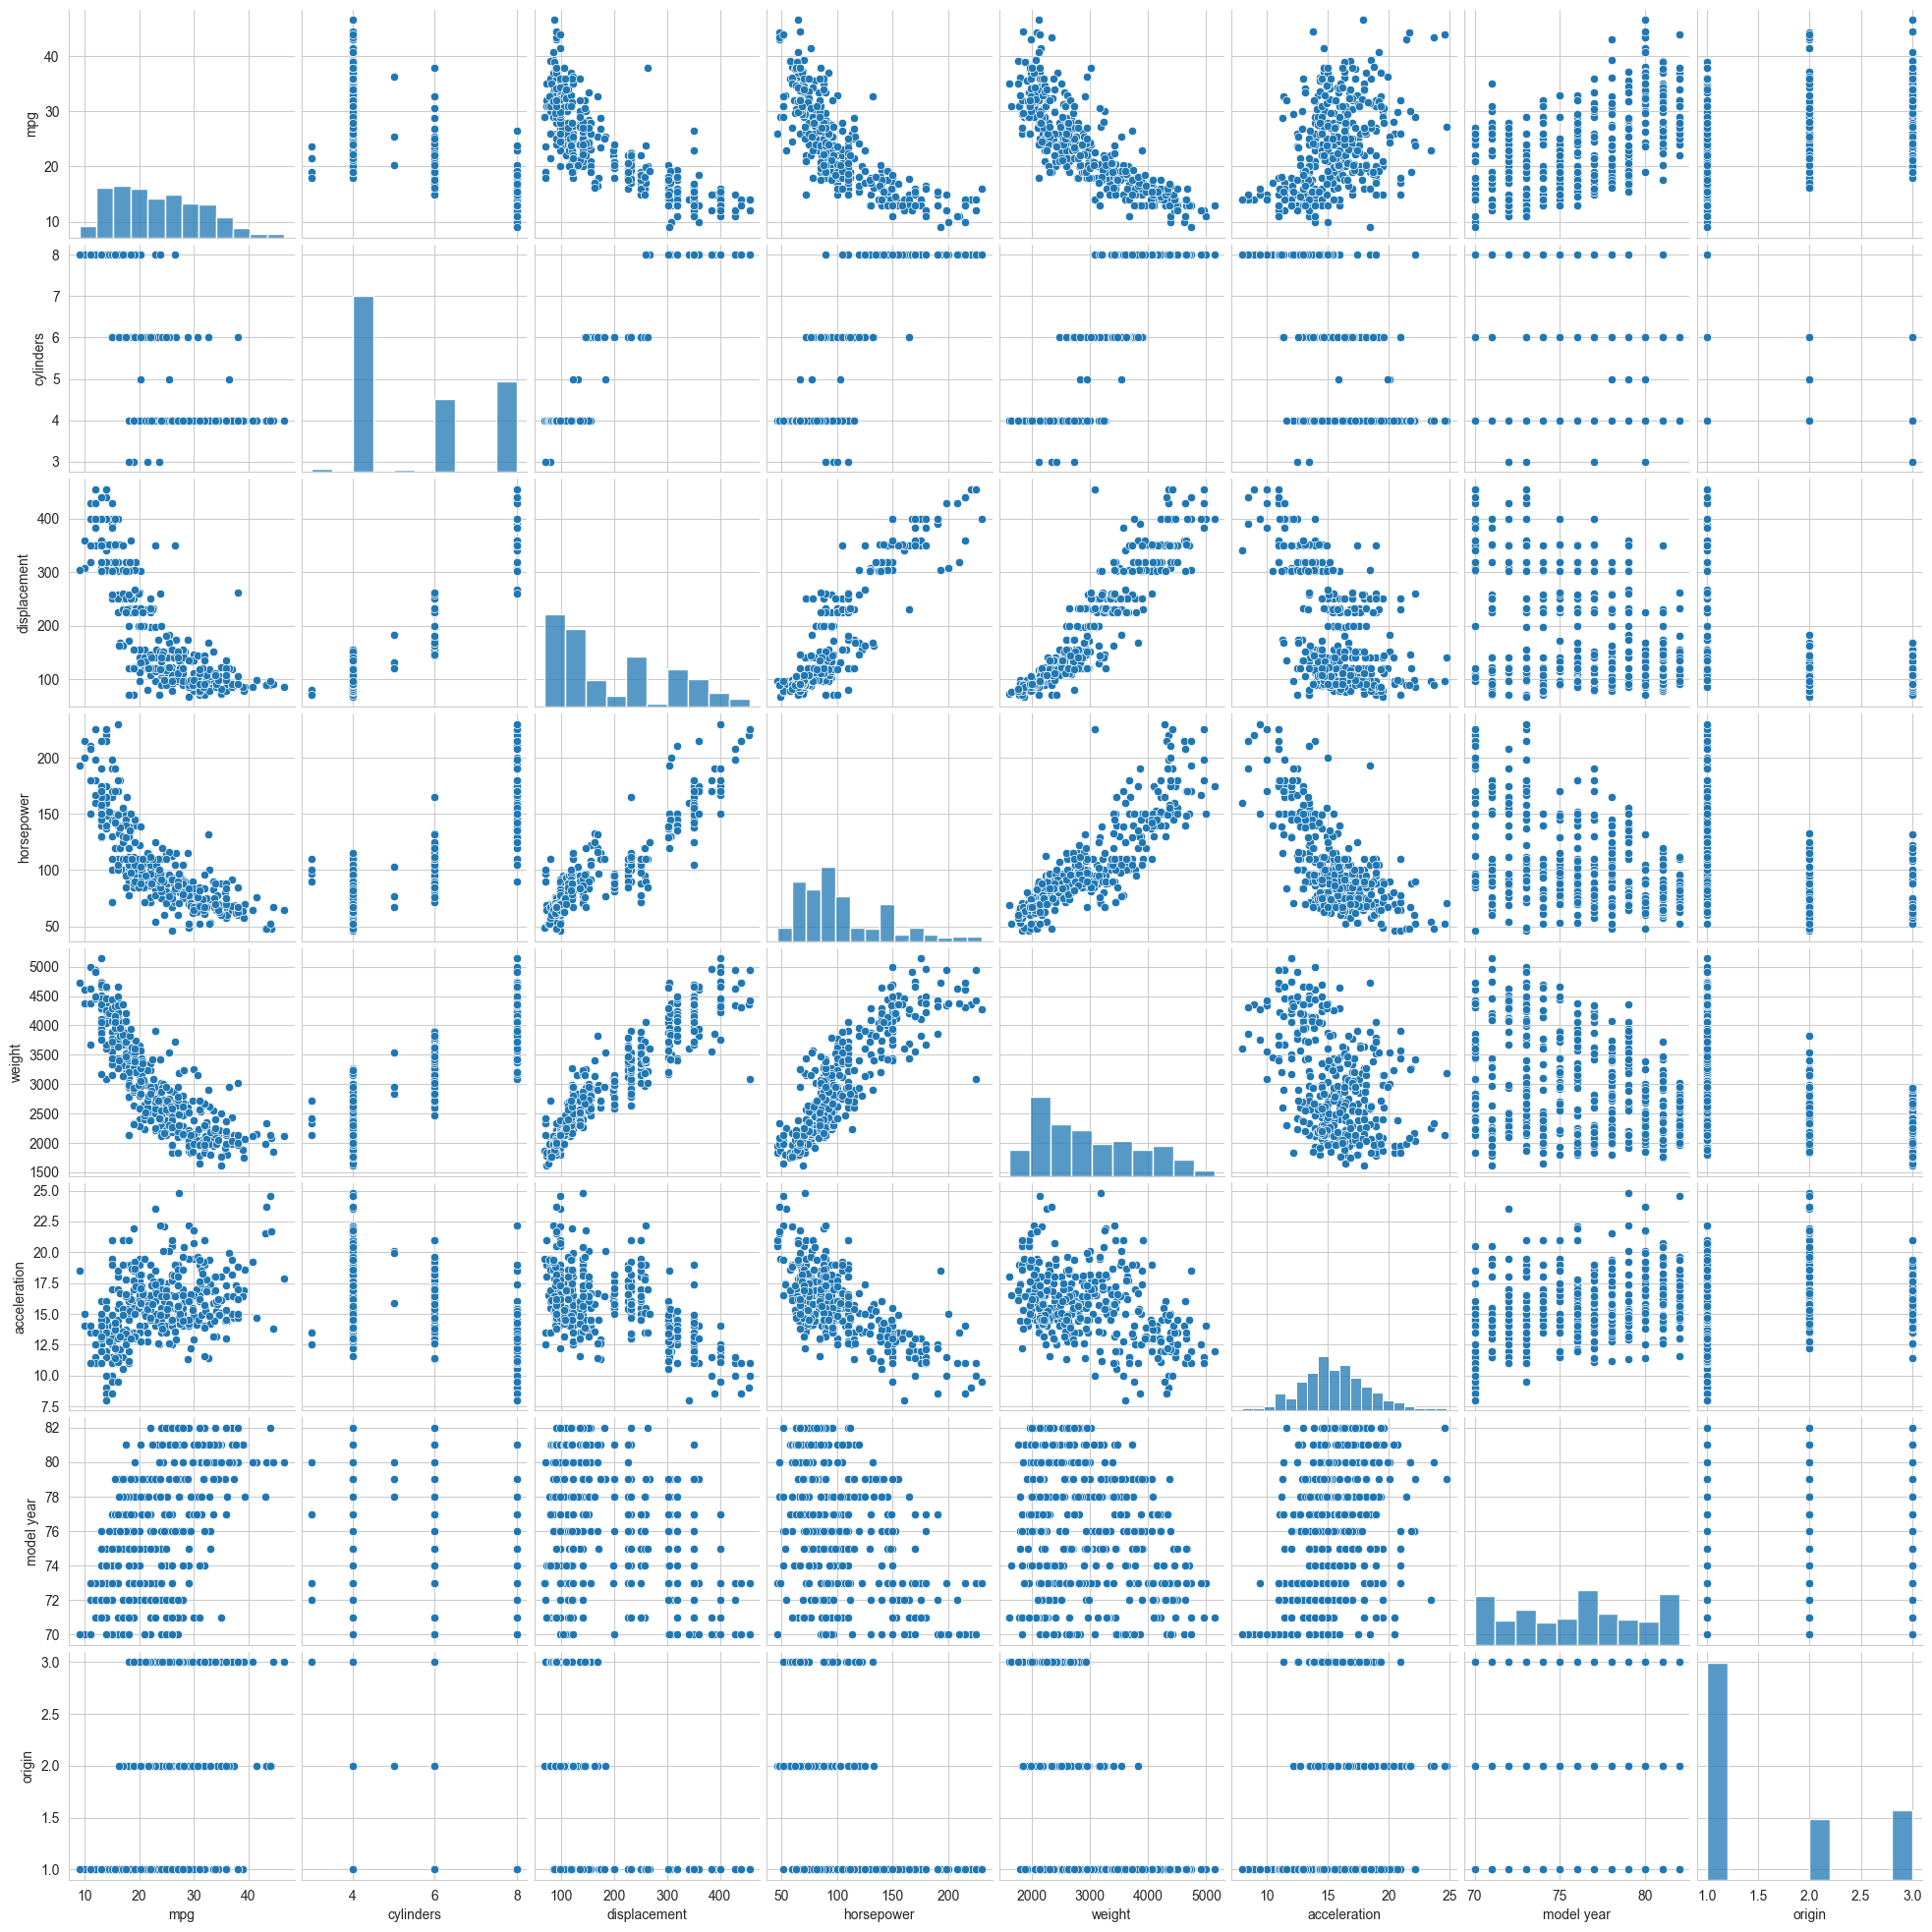

In [11]:
# scatterplots of everything
sns.pairplot(df)
plt.show()


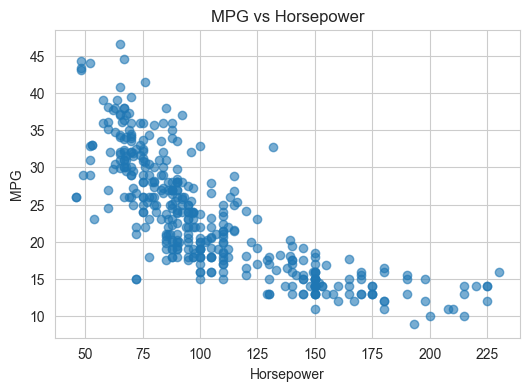

In [12]:
# Visualise a scatter plot between MPG vs Horsepower
plt.figure(figsize=(6,4))
plt.scatter(df['horsepower'],df['mpg'],alpha=0.6)
plt.xlabel('Horsepower')
plt.ylabel('MPG')
plt.title('MPG vs Horsepower')
plt.show()

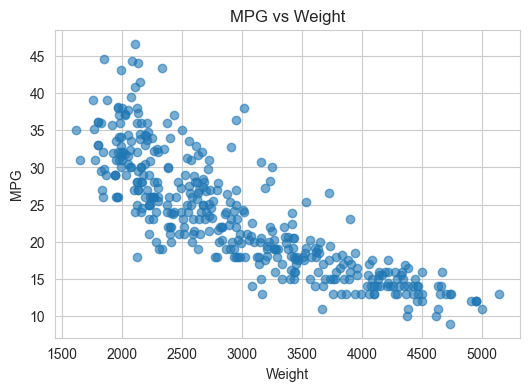

In [13]:
# Visualise a scatter plot between MPG vs Weight
plt.figure(figsize=(6,4))
plt.scatter(df['weight'],df['mpg'],alpha=0.6)
plt.xlabel('Weight')
plt.ylabel('MPG')
plt.title('MPG vs Weight')
plt.show()

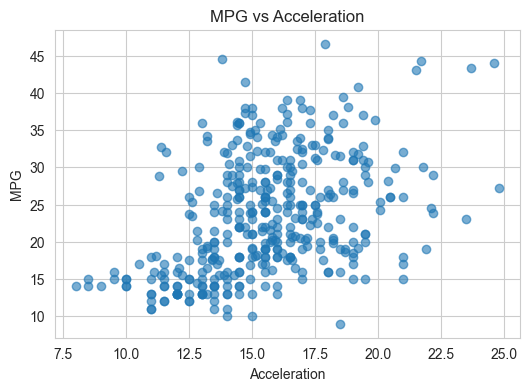

In [14]:
# same but mpg vs acceleration
plt.figure(figsize=(6,4))
plt.scatter(df['acceleration'],df['mpg'],alpha=0.6)
plt.xlabel('Acceleration')
plt.ylabel('MPG')
plt.title('MPG vs Acceleration')
plt.show()

Observations:-
1. MPG vs Weight plot looks more linear because Fuel efficiency is fundamentally about Energy required to move mass so weight directly drives fuel consumption. Weight increase MPG will decrease so it is alomost mechanically linear.


2. But MPG vs Horsepower plot shows more curvature because Low HP → Big jump in MPG, Medium HP → moderate change,High HP → MPG drops sharply. This creates a slight nonlinear (curved) pattern.


3. Acceleration seems slightly positive but much more scattered and less correlated

## Correlation Matrix

In [15]:
# Compute Correlation Matrix
corr_matrix = df.corr(numeric_only=True)

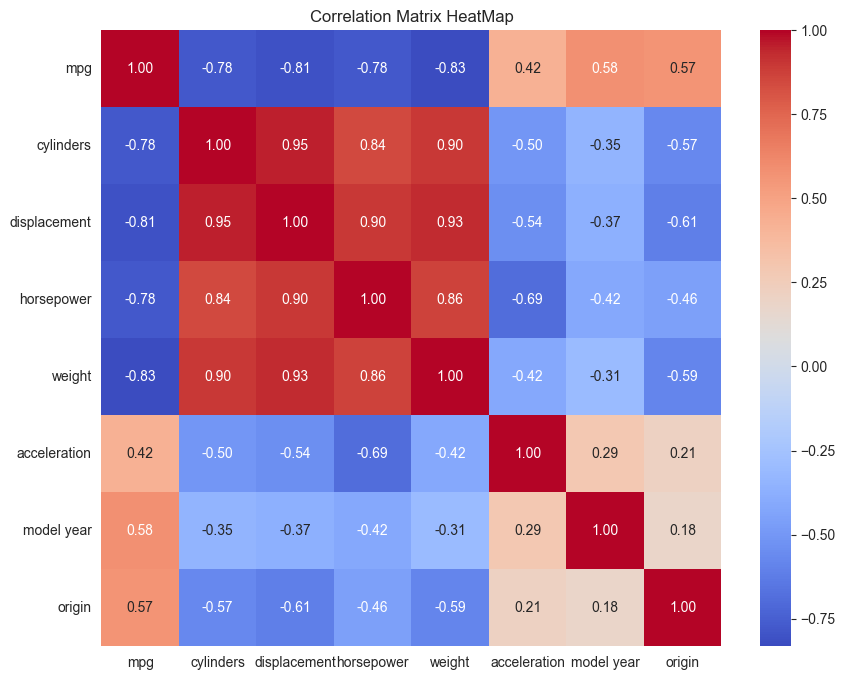

In [16]:
# Visualize HeatMap
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm',fmt='.2f')
plt.title('Correlation Matrix HeatMap')
plt.show()

#### Observations:-
1. Correlation with MPG(Target variable):

    i.) MPG vs Weight: -0.83
    
    ii.) MPG vs Displacement: -0.81
    
    iii.) MPG vs Horsepower: -0.78
    
    iv.) MPG vs Cylinders: -0.78
    
    v.) MPG vs Model: 0.58 (Highest Positive Correlation)


2. Correlation with Predictors:

    i.) Weight vs Horsepower: 0.86
    
    ii.) Weight vs Displacement: 0.93
    
    iii.) Horsepower vs Displacement: 0.90
    
This is very strong multicollinearity which we are seeing here

## Linear Regression Modelling with MPG as Target Var. & Weight as Predictor Variable

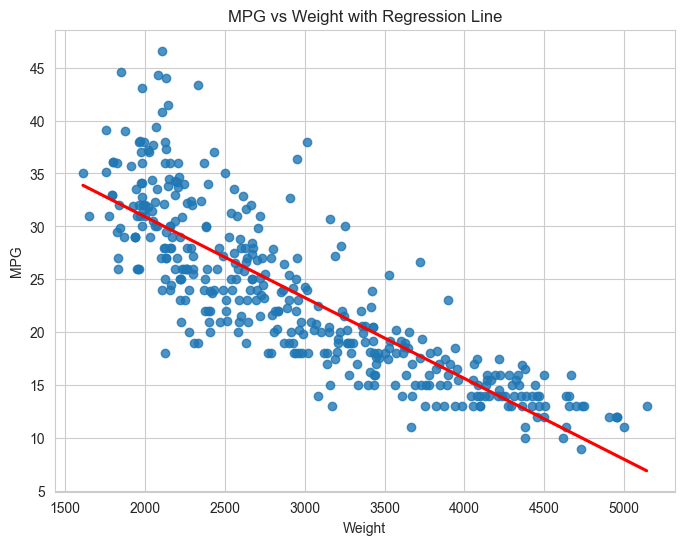

Pearson Correlation:-0.8322


In [17]:

# first try to visualize the relationship with the regression line
plt.figure(figsize=(8,6))
sns.regplot(x=df['weight'],y=df['mpg'],data=df,ci=None,line_kws={'color':'red'})
plt.xlabel('Weight')
plt.ylabel('MPG')
plt.title("MPG vs Weight with Regression Line")
plt.show()

correlation = df['weight'].corr(df['mpg'])
print(f"Pearson Correlation:{correlation:.4f}")

In [18]:
X = df['weight']
Y= df['mpg']

# Add a constant to the independent variable, this is required for statsmodels to calculate the intercept
X_with_const = sm.add_constant(X)

model_weight= sm.OLS(Y,X_with_const).fit()

print(model_weight.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.693
Model:                            OLS   Adj. R-squared:                  0.692
Method:                 Least Squares   F-statistic:                     878.8
Date:                Wed, 11 Mar 2026   Prob (F-statistic):          6.02e-102
Time:                        20:44:03   Log-Likelihood:                -1130.0
No. Observations:                 392   AIC:                             2264.
Df Residuals:                     390   BIC:                             2272.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         46.2165      0.799     57.867      0.0

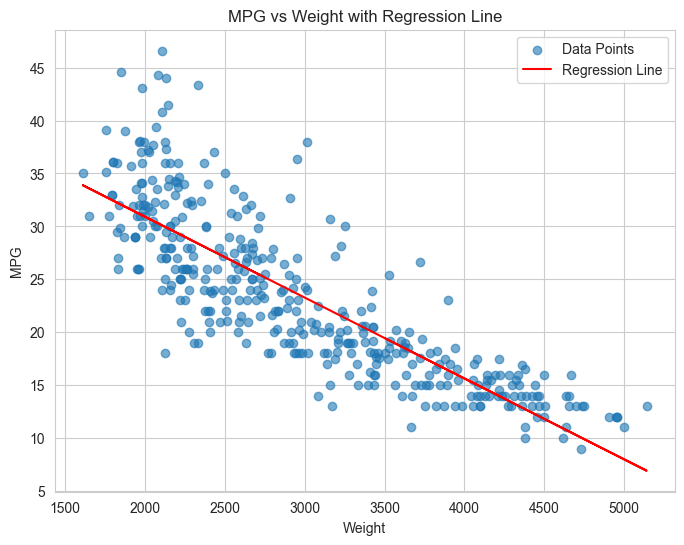

In [19]:
#graph the output of the regression model
plt.figure(figsize=(8,6))
plt.scatter(X,Y,alpha=0.6,label='Data Points')
# Plot the regression line
plt.plot(X, model_weight.predict(X_with_const), color='red', label='Regression Line')
plt.xlabel('Weight')
plt.ylabel('MPG')
plt.title('MPG vs Weight with Regression Line')
plt.legend()
plt.show()




## Make a prediction! ##

In [20]:
print("Predicted MPG for a car weighing 3000 lbs:", model_weight.predict([1, 3000]))

Predicted MPG for a car weighing 3000 lbs: [23.27449694]


### Assessing the model and interpreting the coefficient
Let's Analyse the OLS Table:-
Coefficient: b0+b1*Weight
  1. Intercept: Estimate around 46.2165. If the Weight was 0 then MPG value was 46.2165.
  2. Slope : Estimate around -0.0076.For Every 1 unit increase in weight, MPG decreased by 0.0076.
              for 1000 lps = -0.0076*1000 = -7.6
    
**So the estimated Regression equation = 46.2165-0.0076*weight**

Model Fit:-

R² ≈ 0.693

This means:

*About 69% of the variation in MPG can be explained by vehicle weight alone*

This indicates weight is a very strong predictor of fuel efficiency.

## Linear Regression Modelling with MPG as Target Var. & Acceleration as Predictor Variable

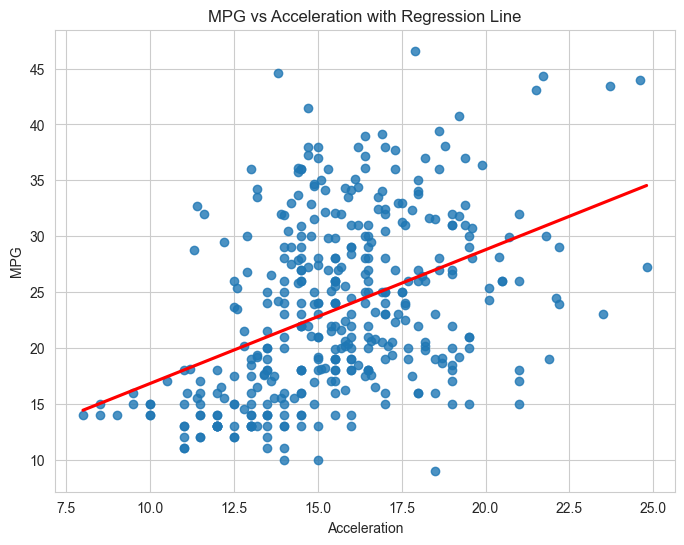

Pearson Correlation: 0.4233


In [21]:
# first try to visualize the relationship with the regression line
plt.figure(figsize=(8,6))
sns.regplot(x=df['acceleration'], y=df['mpg'], data=df, ci=None, line_kws={'color':'red'})
plt.xlabel('Acceleration')
plt.ylabel('MPG')
plt.title("MPG vs Acceleration with Regression Line")
plt.show()

correlation = df['acceleration'].corr(df['mpg'])
print(f"Pearson Correlation: {correlation:.4f}")

In [22]:
X_acc = df['acceleration']
Y_mpg = df['mpg']

# Add a constant to the independent variable, this is required for statsmodels to calculate the intercept
X_acc_with_const = sm.add_constant(X_acc)

model_acc = sm.OLS(Y_mpg, X_acc_with_const).fit()

print(model_acc.summary())
print(f"Estimated Regression equation: MPG = {model_acc.params['const']:.4f} + ({model_acc.params['acceleration']:.4f} * acceleration)")
print(f"R-squared: {model_acc.rsquared:.4f}")

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.179
Model:                            OLS   Adj. R-squared:                  0.177
Method:                 Least Squares   F-statistic:                     85.15
Date:                Wed, 11 Mar 2026   Prob (F-statistic):           1.78e-18
Time:                        20:44:03   Log-Likelihood:                -1322.5
No. Observations:                 392   AIC:                             2649.
Df Residuals:                     390   BIC:                             2657.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            4.8332      2.048      2.359   

### Assessing the model and interpreting the coefficient
Let's Analyse the OLS Table:-

Coefficient:- b0 + b1 * Acceleration
1. Intercept:- Estimate around 4.8332. If acceleration was 0, the predicted MPG is 4.8332.
2. Slope:- Estimate around 1.1976. For every 1 unit increase in acceleration, MPG increases by 1.1976.

**So the estimated Regression equation = 4.8332 + 1.1976 * acceleration**

Model Fit:-

R² ≈ 0.1792

This means:

About 17.9% of the variation in MPG can be explained by acceleration alone.

Compared with weight-based models, acceleration is a weaker standalone predictor of fuel efficiency.

## Residual Analysis

In [23]:
residual = model_weight.resid
fitted_values = model_weight.fittedvalues

In [24]:
model_weight.fittedvalues

0      19.420236
1      17.974889
2      19.940256
3      19.963198
4      19.840840
         ...    
393    24.880439
394    29.927685
395    28.665873
396    26.142250
397    25.415753
Length: 392, dtype: float64

#### Linearity and Homoscedasticity (Residuals vs. Fitted Plot)
Linearity: Residuals should be randomly scattered around zero. A pattern (like a curve) suggests the relationship isn't linear.

Homoscedasticity (Constant Variance): The spread of the residuals should be constant. A funnel shape indicates heteroscedasticity (variance is changing).

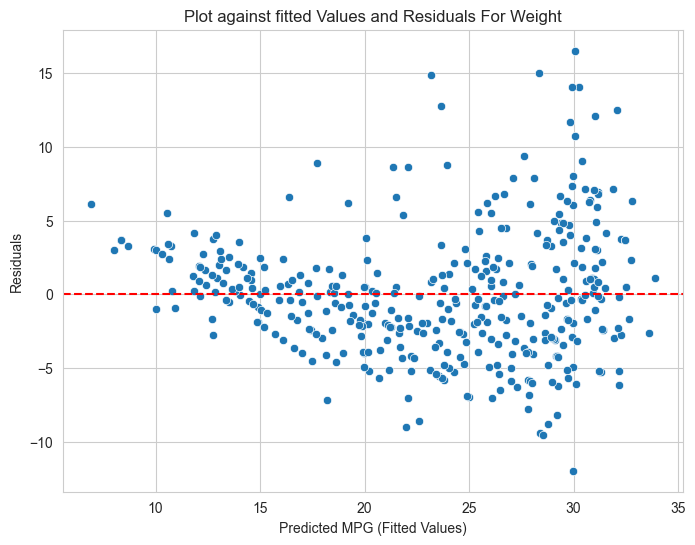

In [25]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=fitted_values,y=residual)
plt.axhline(0,color='red',linestyle='--')
plt.title("Plot against fitted Values and Residuals For Weight")
plt.xlabel('Predicted MPG (Fitted Values)')
plt.ylabel('Residuals')
plt.show()

#### Interpretation:-
1. Our model is better at predicting lower MPG values (basically if you have a lot of Weight we know you do poorly)
2. For higher MPG our accuracy decreases
3. Residuals are fairly even distributed and

#### Limitations of Model1:
This model assumes all the differences in MPG comes from Weight,which is unrealistic because:
* Engine Technology Changes over time.
* Manufacturing Improvement Ocuurs.
* Fuel Efficiency improves over time.

## Adding one more predictor to our model (MPG vs Weight + Model_Year)

In [26]:
X = df[['weight','model year']]
X = sm.add_constant(X)
y = df['mpg']

model_multiple = sm.OLS(y, X).fit()
print(model_multiple.summary())


                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.808
Model:                            OLS   Adj. R-squared:                  0.807
Method:                 Least Squares   F-statistic:                     819.5
Date:                Wed, 11 Mar 2026   Prob (F-statistic):          3.33e-140
Time:                        20:44:03   Log-Likelihood:                -1037.6
No. Observations:                 392   AIC:                             2081.
Df Residuals:                     389   BIC:                             2093.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -14.3473      4.007     -3.581      0.0

### Model2 interpretation:
The estimated Regression equation:
     **MPG = −14.3473−0.0066*weight+0.7573*model_year**
     
Now the model includes technology improvement over time.

**1.  Weight coefficient (-0.0066)**

    Holding model year constant:

   * For every 1-pound increase in weight, MPG decreases by 0.0066 MPG.

    * For 1000 pounds increase, MPG decreases by about 6.6 MPG.

   So heavier cars still have worse fuel efficiency.

**2. Model year coefficient (0.7573)**

    Holding weight constant:

* For every 1-year increase in model year, MPG increases by about 0.76 MPG.

Meaning:

Cars become more fuel-efficient as technology improves.

Over 10 years:
     0.7573*10 = 7.573

So MPG improves by about 7.6 MPG per decade after accounting for weight.

**3. Model Fit**

    R² ≈ 0.808

    Adjusted R² ≈ 0.807

    Interpretation:

    Weight and model year together explain about 81% of the variation in MPG.

This is a substantial improvement over Model 1.

/var/folders/s4/35mz08191h37fr7zq4g0m_d40000gn/T/ipykernel_11679/2188210138.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_surf = model_multiple.params[0] + model_multiple.params[1] * x1_surf + model_multiple.params[2] * x2_surf


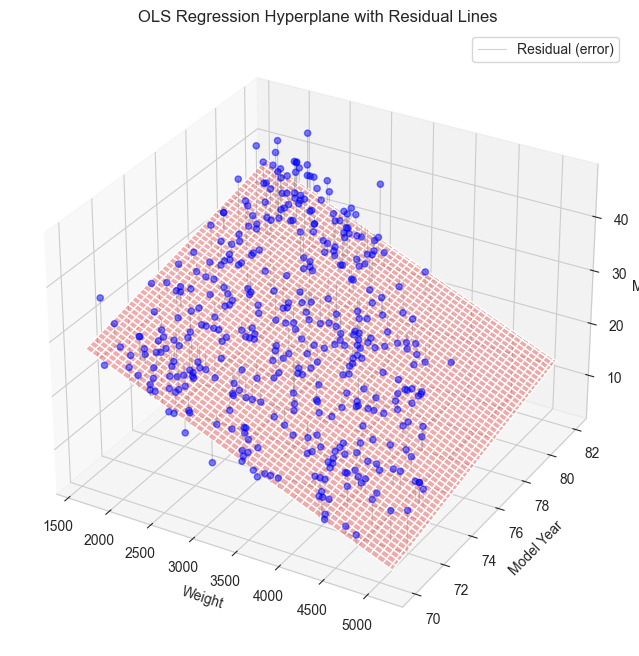

In [27]:
# 3. Create the Hyperplane Grid
x1_surf, x2_surf = np.meshgrid(
    np.linspace(X['weight'].min(), X['weight'].max(), 100),
    np.linspace(X['model year'].min(), X['model year'].max(), 100)
)

# Predicted y values for the plane
y_surf = model_multiple.params[0] + model_multiple.params[1] * x1_surf + model_multiple.params[2] * x2_surf

# Fitted values at observed points (for residual/error lines)
y_fitted = model_multiple.fittedvalues

# 4. Plotting
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot of observed data
ax.scatter(X['weight'], X['model year'], y, c='blue', marker='o', alpha=0.5)

# Add residual lines from hyperplane to observed points
for i, (x1, x2, y_obs, y_hat) in enumerate(zip(X['weight'], X['model year'], y, y_fitted)):
    ax.plot(
        [x1, x1],
        [x2, x2],
        [y_hat, y_obs],
        color='gray',
        alpha=0.35,
        linewidth=0.8,
        label='Residual (error)' if i == 0 else None
    )

# Plot the hyperplane
ax.plot_surface(x1_surf, x2_surf, y_surf, color='red', alpha=0.3)

ax.set_xlabel('Weight')
ax.set_ylabel('Model Year')
ax.set_zlabel('MPG')
ax.set_title('OLS Regression Hyperplane with Residual Lines')
ax.legend()

plt.show()

In [29]:
residual = model_multiple.resid
fitted_values = model_multiple.fittedvalues

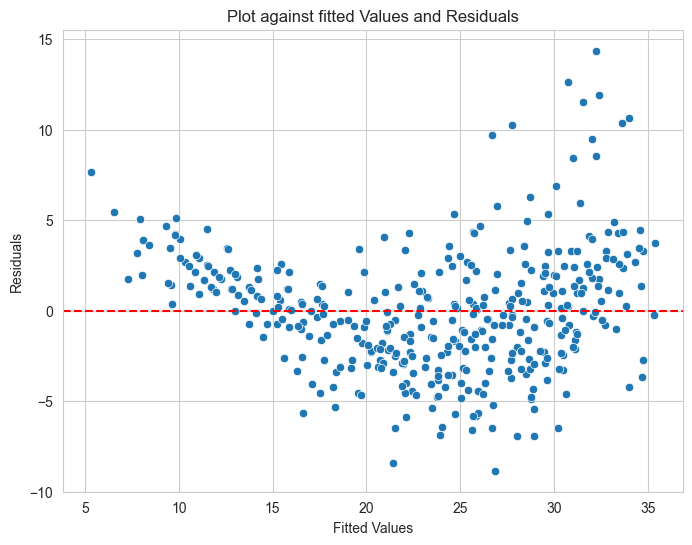

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=fitted_values,y=residual)
plt.axhline(0,color='red',linestyle='--')
plt.title("Plot against fitted Values and Residuals")
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.show()

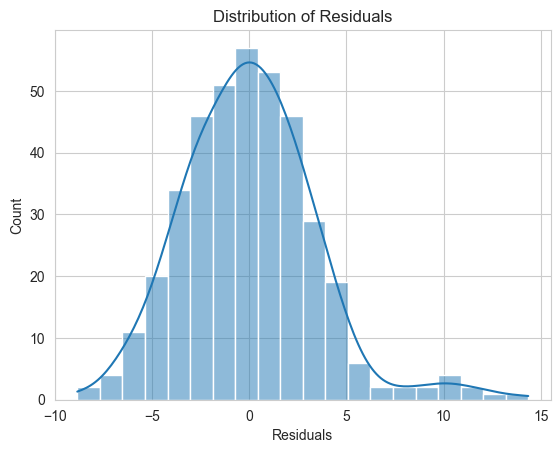

In [ ]:
# Residual Distribution Plot
sns.histplot(residual,kde=True)
plt.title("Distribution of Residuals")
plt.xlabel("Residuals")
plt.show()

## Key Insights from Comparing Models

Model 1:

Weight alone explains 69% of MPG variation.

Model 2:

Weight + technological progress explain 81%.

So, some of the MPG variation previously attributed to weight was actually due to technological improvements over time.

## Final Analytical Conclusion
1. Vehicle weight strongly decreases fuel efficiency.
2. Technology improvement significantly increases MPG.
3. Together, these two variables explain the majority of MPG Variation in the dataset.



## Using categoricals ##


To use a categorical you'll have to create dummy variables for each options available. For our dataset we have 3 different country codes, so we'll create 3 new columns to track whether it belongs to that country

In [36]:
# pd.get_dummies() converts categorical columns into binary (0/1) indicator columns,
# one per unique category. This is called "one-hot encoding."
# drop_first=True drops the first dummy column to avoid multicollinearity
# (the dropped category becomes the baseline/reference group).
# e.g. if 'origin' has values 1, 2, 3 → creates columns 'origin_2' and 'origin_3'
#      a row with origin=1 gets 0 in both new columns (the reference group)
# Set the dtype to int to ensure the dummy variables are integers (0 or 1) instead of boolean
df_encoded = pd.get_dummies(df, columns=['origin'], drop_first=True, dtype=int)

df_encoded.tail()


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,car name,origin_2,origin_3
393,27.0,4,140.0,86.0,2790,15.6,82,ford mustang gl,0,0
394,44.0,4,97.0,52.0,2130,24.6,82,vw pickup,1,0
395,32.0,4,135.0,84.0,2295,11.6,82,dodge rampage,0,0
396,28.0,4,120.0,79.0,2625,18.6,82,ford ranger,0,0
397,31.0,4,119.0,82.0,2720,19.4,82,chevy s-10,0,0


In [37]:
# do a linear regression with the encoded dataset for mpg as the dependent variable and the encoded origin_2 and origin_3 as independent variables
X = df_encoded[['origin_2', 'origin_3']]
Y=df_encoded['mpg']

# add a constant and do the regression
X = sm.add_constant(X)
y = df_encoded['mpg']

model = sm.OLS(y, X).fit()
predictions = model.predict(X)

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.332
Model:                            OLS   Adj. R-squared:                  0.328
Method:                 Least Squares   F-statistic:                     96.60
Date:                Wed, 11 Mar 2026   Prob (F-statistic):           8.67e-35
Time:                        20:54:38   Log-Likelihood:                -1282.2
No. Observations:                 392   AIC:                             2570.
Df Residuals:                     389   BIC:                             2582.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         20.0335      0.409     49.025      0.0

## Interpreting the Regression Output

This OLS model predicts **mpg** using two dummy variables for car origin (`origin_2` = Europe, `origin_3` = Japan), with the US (`origin_1`) as the **reference group** indicated by the const, or y-intercept.

---

### Model Fit
| Metric | Value | Meaning |
|---|---|---|
| **R-squared** | 0.332 | Origin alone explains ~33% of the variation in mpg |
| **F-statistic** | 96.60 | Tests whether the model as a whole is significant |
| **Prob (F-statistic)** | 8.67e-35 | Essentially zero → the model is highly statistically significant |

---

### Coefficients
| Term | Coef | Interpretation |
|---|---|---|
| **const** | 20.03 | Baseline average mpg for US cars (`origin_1`) |
| **origin_2** | +7.57 | European cars average **7.57 mpg more** than US cars |
| **origin_3** | +10.42 | Japanese cars average **10.42 mpg more** than US cars |

All three coefficients have **p-values < 0.05** (shown in the `P>|t|` column as 0.000), meaning the differences are statistically significant. The 95% confidence intervals (`[0.025, 0.975]`) confirm this — none of the intervals cross zero.
